# Uncertainty propagation

Uncertainty is ubiquitous in engineering design. For example, manufacturing processes create deviations from specifications, the system operating and loading conditions may vary, and some parameters are just inherently variable. Furthermore, the engineering models used in the design can be over simplified which introduces uncertainties. All of these can have a direct impact on the engineered system and its performance. Quantifying the impacts of uncertainties on the system is therefore an important part of the engineering design process.

Uncertainty quantification (UQ) is a widely used tool in various science and engineering applications to quantify the impact of uncertainties on model outputs. It consists of three steps: (i) identifying the type of uncertainty in model parameters, (ii) using a mathematical framework to quantify this uncertainty (in most cases, probability theory), and (iii) uncertainty propagation (UP) (also known as forward UQ). The UP consists of propagating randomness in parameters through the model to quantify uncertainty in model output.

This section describes how to perform UP using Monte Carlo simulation (MCS), which involves repeated sampling from the distribution of uncertain input parameters and then computing model output for each sample. These computed model outputs can be used for estimating statistics, such as mean and standard deviation, or to plot the probability distribution of model output. In this way, MCS can be used for propagating uncertainty through the model. Refer to lecture notes for more details.

> __NOTE__: We are using [seaborn](https://seaborn.pydata.org/) for visualizing distributions. It is a very powerful statistical data visualization package in Python. Install seaborn using `pip install seaborn`.

Below code blocks import required packages:

In [1]:
import numpy as np
import seaborn as sns
from pyDOE3 import halton_sequence
import matplotlib.pyplot as plt
from scipy.stats import uniform

## MCS

In this section, MCS is demonstrated using ishigami function which is written as

$$
    f(\mathbf{x}) = \sin(x_1) + 7\sin^2(x_2) + 0.05 x_3^4 \sin(x_1).
$$

Each input variable follows a uniform distribution, given by

$$
    X_i \sim \mathbb{U}[-\pi,\pi], \forall \text{ } i = 1,2,3. 
$$

Due to this uncertainty in input parameters, output of the ishigami function is uncertain. So, the goal here is to quantify this uncertainty in function output.

Below code block defines ishigami function:

In [2]:
def ishigami(x):

    x = np.atleast_2d(x)

    return np.sin(x[:,0]) + 7*np.sin(x[:,1])**2 + 0.1*x[:,2]**4 * np.sin(x[:,0])

Below code block defines uniform random variable (rv) for each input parameter. We are using `uniform` class from `scipy.stats` for defining rv. The two primary inputs to this class are - `loc` and `scale`. The `loc` argument defines the starting point of the specified range while the `scale` argument refers to the range itself. For example, if you want to define a uniform rv with a range of [2,5], then you need to define `loc=2` and `scale=3`. You can read more about `uniform` class [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html). You can also create a normally distributed variable using [`norm`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) class from `scipy.stats`, refer [here](https://docs.scipy.org/doc/scipy/reference/stats.html#continuous-distributions) for the full list of distributions.

In [3]:
# Defining random variables
rv_x1 = uniform(loc=-np.pi, scale=2*np.pi)
rv_x2 = uniform(loc=-np.pi, scale=2*np.pi)
rv_x3 = uniform(loc=-np.pi, scale=2*np.pi)

### Propagation

Once random variables are defined, next step is to draw samples from the input parameter distribution and compute the value of function for each sample.

> __NOTE__: You can also just define a single uniform random variable and generate samples with `size=(N_samples,3)`

Below code block randomly draws samples from the input parameter distribution, evaluates the function at those samples, and then computes statistics (mean and standard deviation) of function output. This process is repeated for different number of samples to see how the statistics evolve with increasing number of samples.

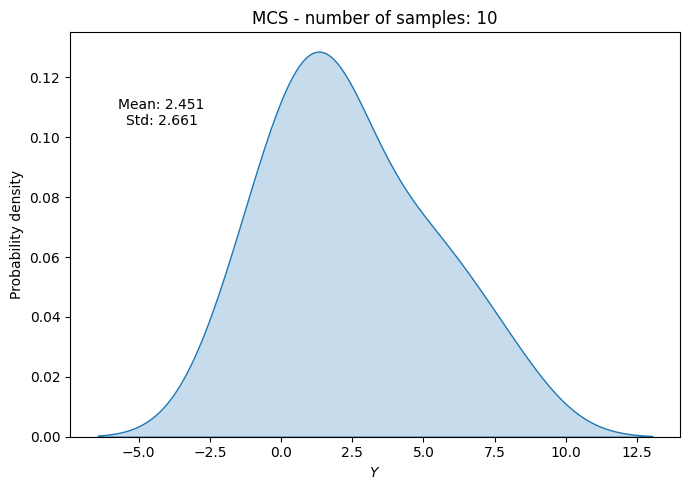

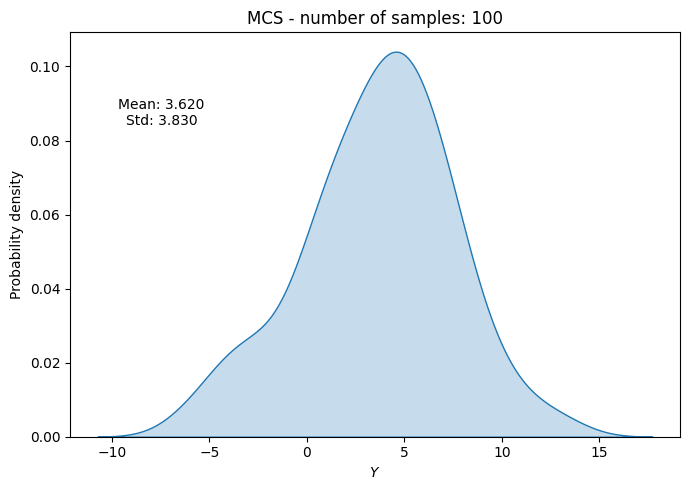

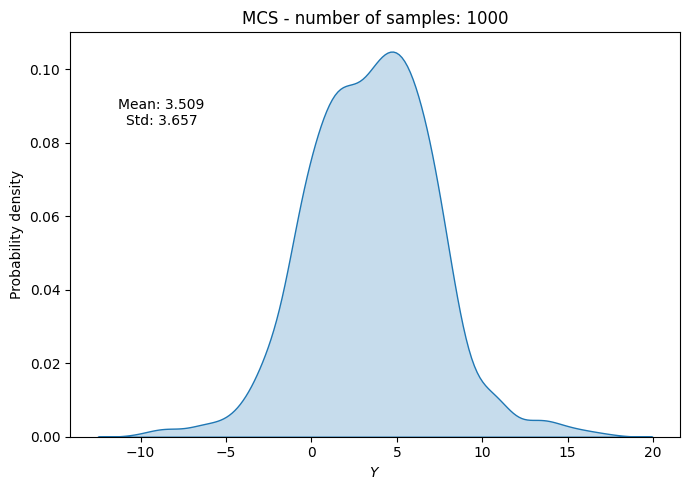

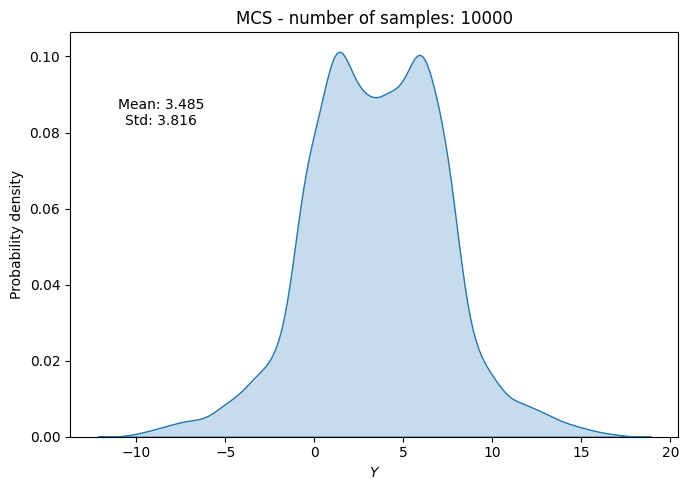

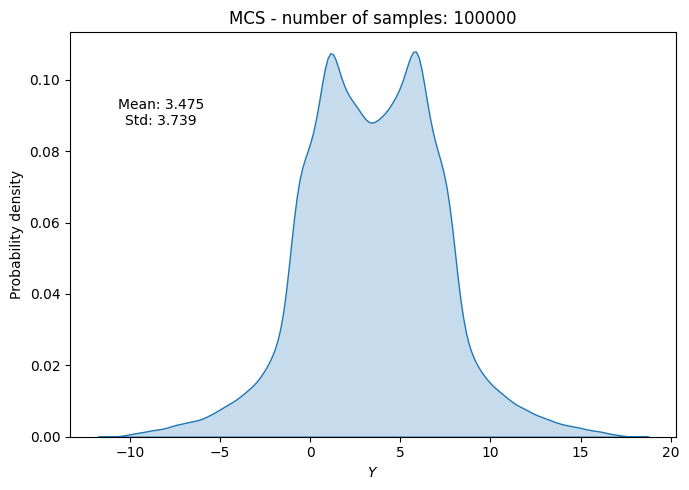

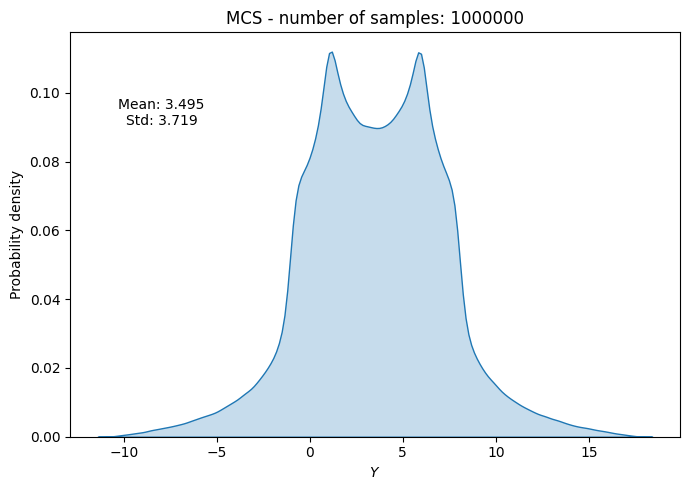

In [4]:
# number of samples
samples = [10, 100, 1000, 10000, 100000, 1000000]

# empty list to store results
mean_random = []
std_random = []
f_values_random = []

# Loop through each sample size
for sample in samples:

    # randomly drawn samples
    x_samples = np.hstack((
        rv_x1.rvs(size=sample).reshape(-1,1),
        rv_x2.rvs(size=sample).reshape(-1,1),
        rv_x3.rvs(size=sample).reshape(-1,1),
    ))

    # evaluate function at the samples
    f_values = ishigami(x_samples)

    del x_samples

    # store statistics and pdf
    f_values_random.append(f_values)
    mean_random.append(np.mean(f_values))
    std_random.append(np.std(f_values))

    # Plot PDF of function output
    fig, ax = plt.subplots(figsize=(7,5))
    sns.kdeplot(x=f_values, fill=True, ax=ax)
    ax.set_ylabel("Probability density")
    ax.set_xlabel("$Y$")
    ax.set_title("MCS - number of samples: {}".format(sample))
    ax.annotate(f"Mean: {mean_random[-1]:.3f}\nStd: {std_random[-1]:.3f}", xy=(0.15, 0.8), xycoords="axes fraction", va="center", ha="center")
    plt.tight_layout()
    plt.show()

### Convergence

To check the convergence of MCS, we can plot the evolution of statistics of interest (e.g., mean and standard deviation) as a function of the number of samples. We can also compute a convergence metric such as the absolute relative change in mean and standard deviation with respect to the number of samples. Specifically, we can compute this relative change as

$$
    \text{relative change} = \Bigg| \frac{\text{statistic}_{n} - \text{statistic}_{n-1}}{\text{statistic}_{0}} \Bigg|,
$$

where $\text{statistic}_{n}$ and $\text{statistic}_{n-1}$ are the statistics of interest computed at $n^{th}$ and $n-1^{th}$ iteration, respectively. The $\text{statistic}_{0}$ is the statistic computed in the first iteration. This relative change can be plotted as a function of the number of samples to check for convergence.

Below code block plots the evolution of mean and standard deviation as a function of the number of samples. It also plots the above convergence metric. 

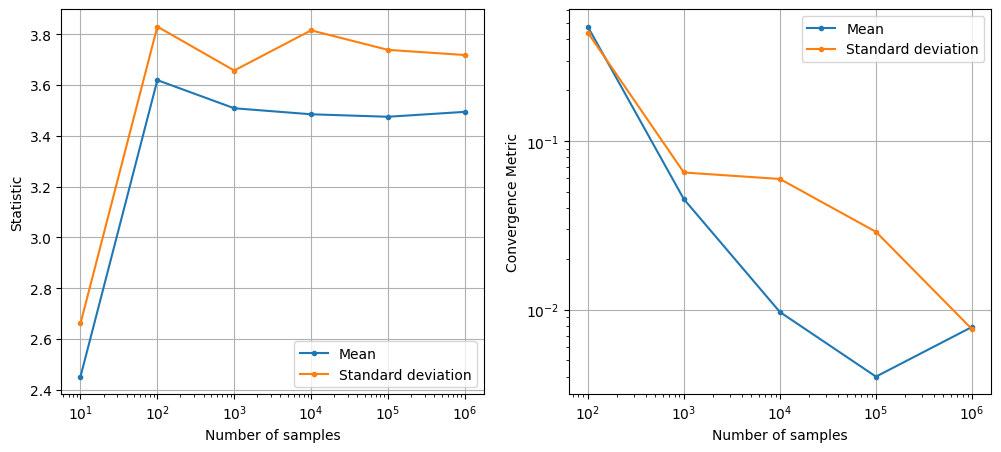

In [5]:
conv_mean_random = np.abs(np.diff(mean_random)/mean_random[0])
conv_std_random = np.abs(np.diff(std_random)/std_random[0])

fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].plot(samples, mean_random, marker=".", label="Mean")
ax[0].plot(samples, std_random, marker=".", label="Standard deviation")
ax[0].grid()
ax[0].legend()
ax[0].set_ylabel("Statistic")
ax[0].set_xlabel("Number of samples")
ax[0].set_xscale("log")

ax[1].plot(samples[1:], conv_mean_random, marker=".", label="Mean")
ax[1].plot(samples[1:], conv_std_random, marker=".", label="Standard deviation")
ax[1].grid()
ax[1].legend()
ax[1].set_ylabel("Convergence Metric")
ax[1].set_xlabel("Number of samples")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

As can be seen in above plots, the mean and standard deviation converges to a specific value as the number of samples increases. However, MCS is computationally expensive as it requires a large number of function evaluations to get accurate estimates of statistics. This is because the rate of convergence of MCS is slow (i.e., the error decreases as $1/\sqrt{N}$ where $N$ is the number of samples).

> __NOTE__: This slow convergence of MCS is a major drawback, especially when each function evaluation is expensive (e.g., it requires running a computationally expensive simulation). In such cases, it may not be feasible to perform MCS directly using the true function. As a result, surrogate models are often used to approximate the true function and perform MCS using the surrogate model instead.

## MCS with Halton sequence

In previous section, MCS was performed by drawing random samples from the input parameter distribution. This usually leads to clustering of samples in some regions of the input space and sparse sampling in other regions. As a result, the estimates of statistics can be inaccurate and the convergence can be slow. To address this issue, we can use a better sampling technique such as Halton sequence which ensures that samples are more evenly distributed across the input space. Moreover, previous generated samples from Halton sequence can be reused when we increase the increase of number of samples.

However, sampels generated using Halton sequence do not follow the desired distribution of input parameters. It just generates samples that are distributed within a unit hypercube (i.e., $[0,1]^d$ where $d$ is the number of input parameters. This can be thought of as generating samples from a standard uniform distribution. Note that we only the distribution of input parameters, we do not have any upper/lower bound on the input parameters.

To convert these standard uniform samples to the desired distribution of input parameters, we need to use the inverse transform sampling method. This method involves applying the inverse cumulative distribution function (CDF) of the desired distribution to the standard uniform samples generated by Halton sequence. Mathematically, this can be written as

$$
    x = F^{-1}(x_{halton}),
$$

where $F^{-1}$ is the inverse cumulative distribution function (CDF) of the input parameter distribution and $x_{halton}$ is the sample generated by Halton sequence.

Below code block demonstrates MCS using Halton sequence for the ishigami function. We will be using `halton_sequence` function from `pyDOE3` package for generating Halton sequence samples. To perform inverse transform sampling, we will be using `ppf` method (percent point function) from the defined random variable in previous section. The `ppf` method computes the inverse CDF of the random variable.

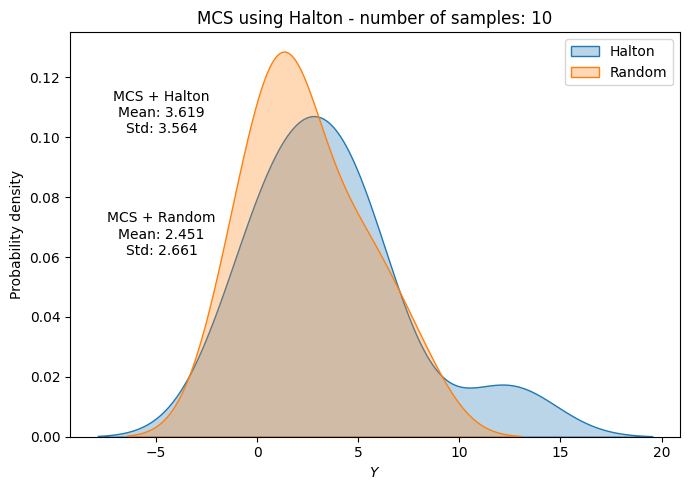

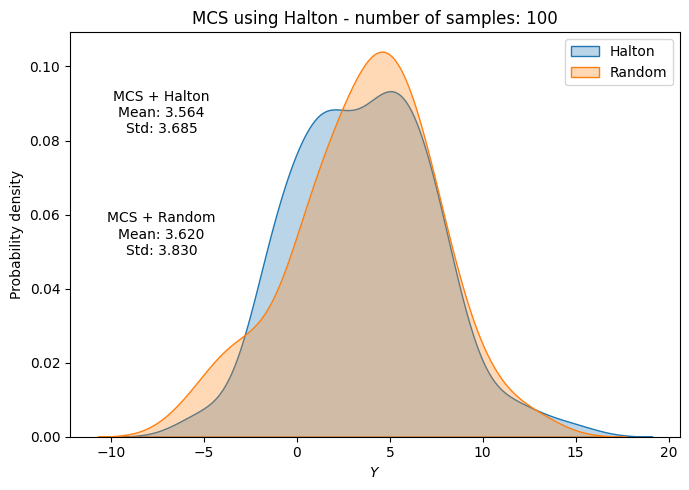

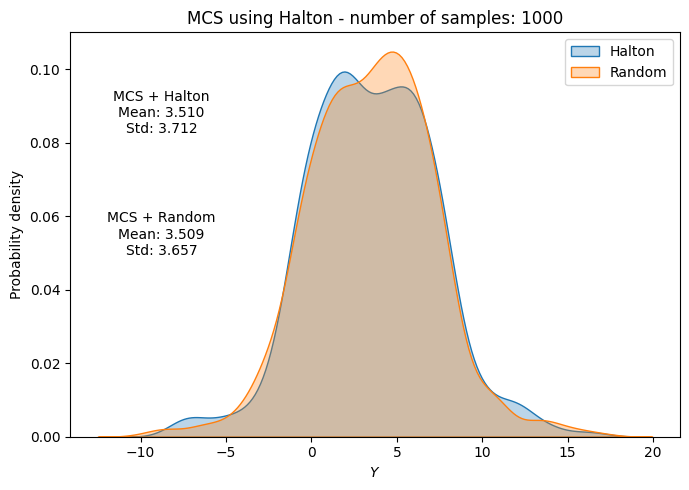

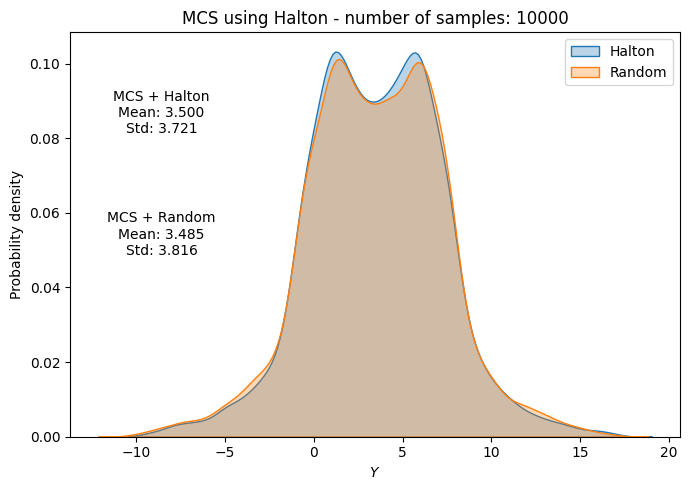

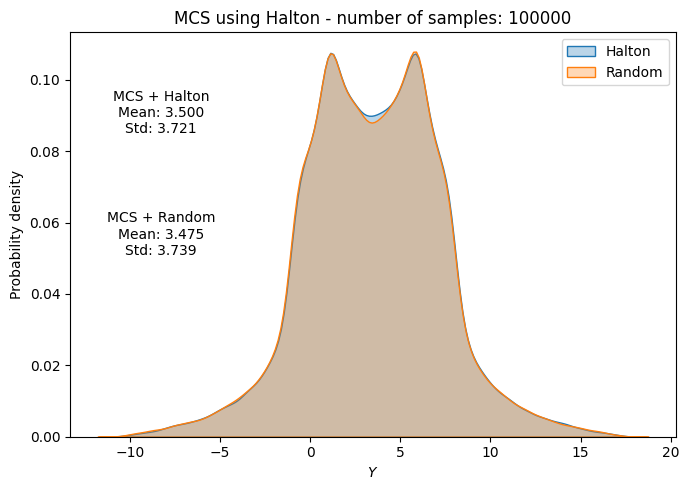

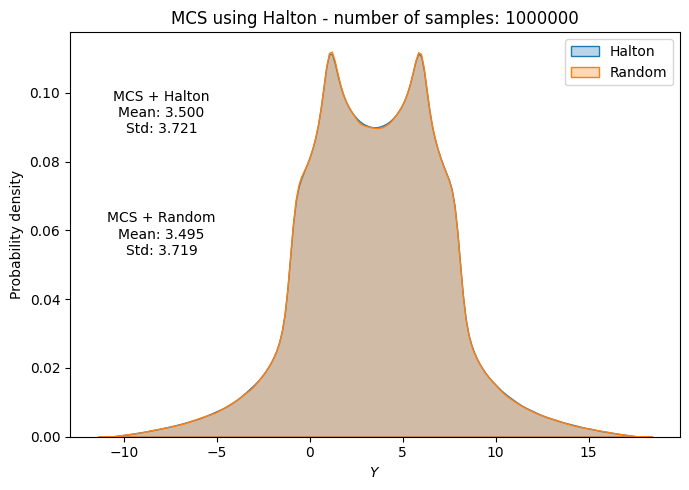

In [6]:
# number of samples
samples = [10, 100, 1000, 10000, 100000, 1000000]

# empty list to store results
mean_halton = []
std_halton = []

# loop through each sample size
for i, sample in enumerate(samples):
    
    halton_samples = halton_sequence(num_points=sample, dimension=3)

    # randomly drawn samples
    x_samples = np.hstack((
        rv_x1.ppf(halton_samples[:,0]).reshape(-1,1),
        rv_x2.ppf(halton_samples[:,1]).reshape(-1,1),
        rv_x3.ppf(halton_samples[:,2]).reshape(-1,1),
    ))

    del halton_samples

    # evaluate function at the samples
    f_values = ishigami(x_samples)

    # compute statistics
    mean_halton.append(np.mean(f_values))
    std_halton.append(np.std(f_values))

    # Plot PDF of function output
    fig, ax = plt.subplots(figsize=(7,5))
    sns.kdeplot(x=f_values, fill=True, ax=ax, label="Halton", alpha=0.3)
    sns.kdeplot(x=f_values_random[i], fill=True, ax=ax, label="Random", alpha=0.3)
    ax.legend()
    ax.set_ylabel("Probability density")
    ax.set_xlabel("$Y$")
    ax.set_title("MCS using Halton - number of samples: {}".format(sample))
    ax.annotate(f"MCS + Halton\nMean: {mean_halton[-1]:.3f}\nStd: {std_halton[-1]:.3f}", xy=(0.15, 0.8), xycoords="axes fraction", va="center", ha="center")
    ax.annotate(f"MCS + Random\nMean: {np.mean(f_values_random[i]):.3f}\nStd: {np.std(f_values_random[i]):.3f}", xy=(0.15, 0.5), xycoords="axes fraction", va="center", ha="center")
    plt.tight_layout()
    plt.show()

    del x_samples, f_values

Below code block plots the evolution of mean and standard deviation as a function of the number of samples for MCS using Halton sequence. It also plots the convergence metric. For comparison, it also plots the results from MCS using random sampling.

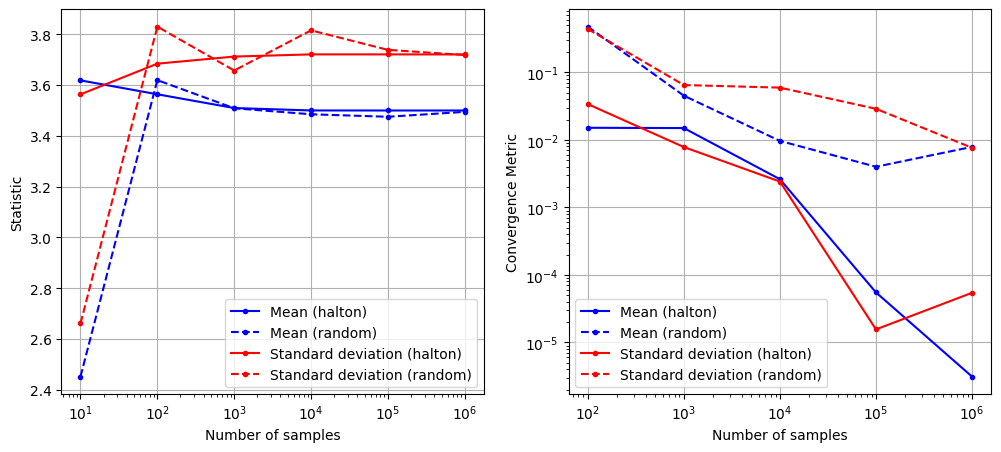

In [7]:
conv_mean_halton = np.abs(np.diff(mean_halton)/mean_halton[0])
conv_std_halton = np.abs(np.diff(std_halton)/std_halton[0])

fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].plot(samples, mean_halton, "b-", marker=".", label="Mean (halton)")
ax[0].plot(samples, mean_random, "b--", marker=".", label="Mean (random)")
ax[0].plot(samples, std_halton, "r-", marker=".", label="Standard deviation (halton)")
ax[0].plot(samples, std_random, "r--", marker=".", label="Standard deviation (random)")
ax[0].grid()
ax[0].legend()
ax[0].set_ylabel("Statistic")
ax[0].set_xlabel("Number of samples")
ax[0].set_xscale("log")

ax[1].plot(samples[1:], conv_mean_halton, "b-", marker=".", label="Mean (halton)")
ax[1].plot(samples[1:], conv_mean_random, "b--", marker=".", label="Mean (random)")
ax[1].plot(samples[1:], conv_std_halton, "r-", marker=".", label="Standard deviation (halton)")
ax[1].plot(samples[1:], conv_std_random, "r--", marker=".", label="Standard deviation (random)")
ax[1].grid()
ax[1].legend()
ax[1].set_ylabel("Convergence Metric")
ax[1].set_xlabel("Number of samples")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

As can be seen in above plots, the mean and standard deviation converges to a specific value as the number of samples increases. Moreover, the convergence is much faster compared to MCS with random sampling.